In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import os
import numpy as np
import glob

In [2]:
batch_sizes = (32, 64, 128)
modes = ('onfly', 'preload')
mode_label = {"onfly": "on-the-fly",
              "preload": "before training"}
# styles
colours = {32: "tab:blue", 64: "tab:orange", 128: "tab:green"}
linestyles = {"onfly": "solid", "preload": "dashed"}

In [3]:
data_dir = os.path.join(os.getcwd(), 'final_data_analysis', 'energy_data')
plot_dir = os.path.join(os.getcwd(), 'final_plots', 'energy')

In [4]:
data_files = glob.glob(os.path.join(data_dir, "*.csv"))

In [5]:
# files for step
step_files = [f for f in data_files if "steps" in f]
step_summary_files = [f for f in data_files if "step_rank_0.csv" in f]

In [6]:
print(f"Number of step files: {len(step_files)}, Number of step summary files: {len(step_summary_files)}")

Number of step files: 18, Number of step summary files: 18


In [7]:
def get_params_from_filename(file):
    """
    Inputs:
        file: str, full file path
    Outputs:
        batch_size: int
        num_workers: int
        num_samples: int
        repeat: int
    """
    file_name = os.path.basename(file)
    
    batch_size = int(file_name.split("_batch-")[1].split("_work-")[0])
    num_workers = int(file_name.split("_work-")[1].split("_samples-")[0])
    num_samples = int(file_name.split("_samples-")[1].split("_repeat-")[0])
    repeat = int(file_name.split("_repeat-")[1].split("_labels-")[0])
    total_samples = num_samples * repeat
    mode = file_name.split("_cc")[0].split("_")[-1]

    return batch_size, num_workers, total_samples, mode

Combine the files with same batch size and mode in an averaged dataframe

In [8]:
data_dict = {} # (mode, batch size): concatenated df with all info about all runs
for file in step_files:
    batch_size, num_workers, total_samples, mode = get_params_from_filename(file)
    df = pd.read_csv(file)
    
    # remove first and last data point
    df = df.iloc[1:-1]

    # reformat the timestamp column to get an approximate timestamp starting at 0
    df["timestamp"] = pd.to_datetime(df["timestamp"])
    df["timestamp"] = (df["timestamp"] - df["timestamp"].iloc[0]).dt.total_seconds()
    
    # only keep relevant columns
    df = df[["timestamp",
            "duration", 
             "emissions", 
             "cpu_power", 
             "gpu_power", 
             "ram_power", 
             "cpu_energy", 
             "gpu_energy", 
             "ram_energy", 
             "energy_consumed"]]

    if (mode, batch_size) not in data_dict:
        data_dict[(mode, batch_size)] = df

    else:
        # concatenate data to end of df
        data_dict[(mode, batch_size)] = pd.concat([data_dict[(mode, batch_size)], df])

In [9]:
# get the average per iteration across runs
for (mode, batch_size) in data_dict:
    data_dict[(mode, batch_size)] = data_dict[(mode, batch_size)].groupby(level=0).mean()

Duration of each step over time.

Text(0.5, 0.98, 'Duration per step')

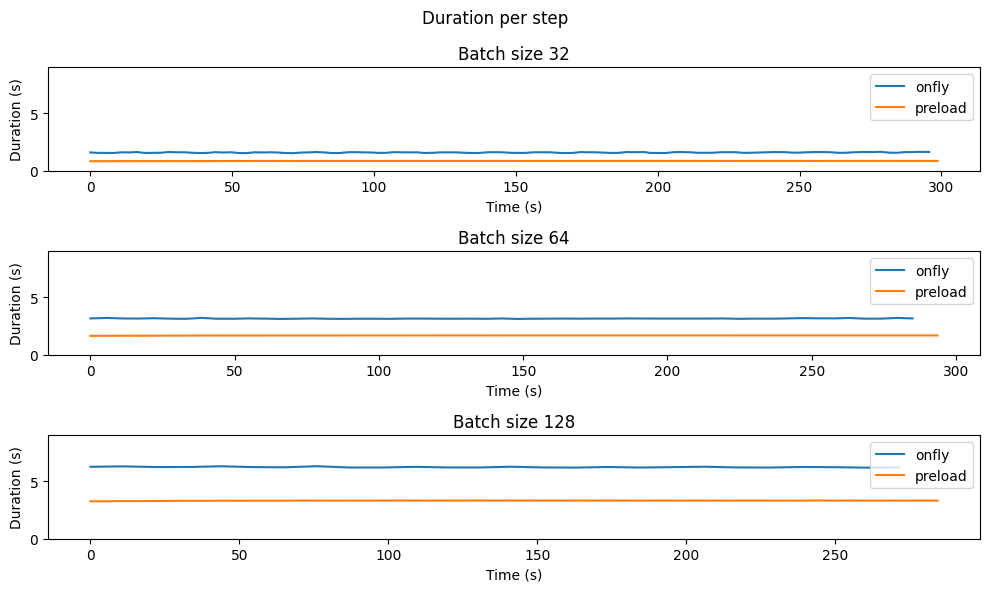

In [10]:
fig, ax = plt.subplots(3, 1, figsize=(10, 6), layout="tight")

for i, b in enumerate(batch_sizes):
    for m in modes:
        data = data_dict[(m, b)]
        ax[i].plot(data["timestamp"], data["duration"], label=m)
        ax[i].set_title(f"Batch size {b}")
        ax[i].set_xlabel("Time (s)")
        ax[i].set_ylabel("Duration (s)")
        ax[i].legend()
        ax[i].set_ylim(0, 9)

fig.suptitle("Duration per step")

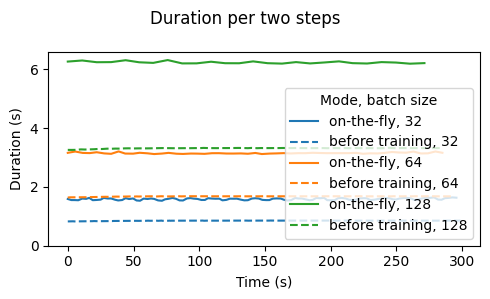

In [11]:
# combine all in one graph
fig, ax = plt.subplots(figsize=(5, 3), layout="tight")

for i, b in enumerate(batch_sizes):
    for m in modes:

        if m == "onfly":
            linestyle = "solid"
        else:
            linestyle = "dashed"
        data = data_dict[(m, b)]
        ax.plot(data["timestamp"], data["duration"], label=f"{mode_label[m]}, {b}", linestyle=linestyles[m], color=colours[b])
        ax.set_xlabel("Time (s)")
        ax.set_ylabel("Duration (s)")

ax.legend(loc="lower right", title="Mode, batch size")
ax.set_ylim(0)
fig.suptitle("Duration per two steps")
fig.savefig(os.path.join(plot_dir, "duration_per_step.png"))

Emissions over time

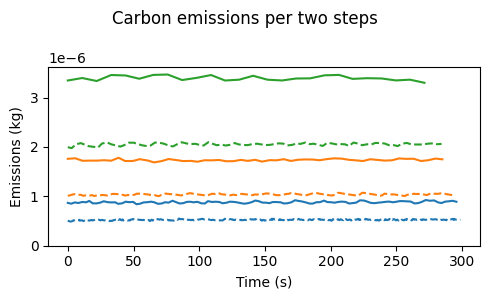

In [12]:
# combine all in one graph
fig, ax = plt.subplots(figsize=(5, 3), layout="tight")

for i, b in enumerate(batch_sizes):
    for m in modes:
        data = data_dict[(m, b)]
        ax.plot(data["timestamp"], data["emissions"], label=f"{m}, {b}", linestyle=linestyles[m], color=colours[b])
        ax.set_xlabel("Time (s)")
        ax.set_ylabel("Emissions (kg)")

ax.set_ylim(0)
fig.suptitle("Carbon emissions per two steps")
fig.savefig(os.path.join(plot_dir, "carbon_emissions_step.png"))

Power over time

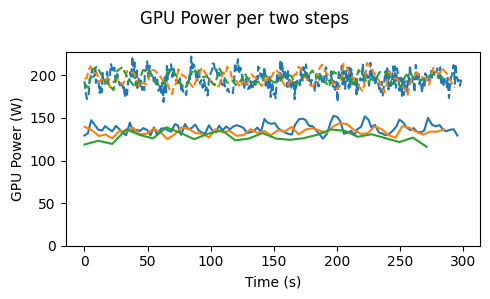

In [13]:
# combine all in one graph
fig, ax = plt.subplots(figsize=(5, 3), layout="tight")

for i, b in enumerate(batch_sizes):
    for m in modes:
        data = data_dict[(m, b)]
        ax.plot(data["timestamp"], data["gpu_power"], label=f"{mode_label[m]}, {b}", linestyle=linestyles[m], color=colours[b])
        ax.set_xlabel("Time (s)")
        ax.set_ylabel("GPU Power (W)")
        
ax.set_ylim(0)
fig.suptitle("GPU Power per two steps")
fig.savefig(os.path.join(plot_dir,  "gpu_power_step.png"), dpi=300, bbox_inches="tight")

Text(0.5, 0.98, 'GPU Power per step')

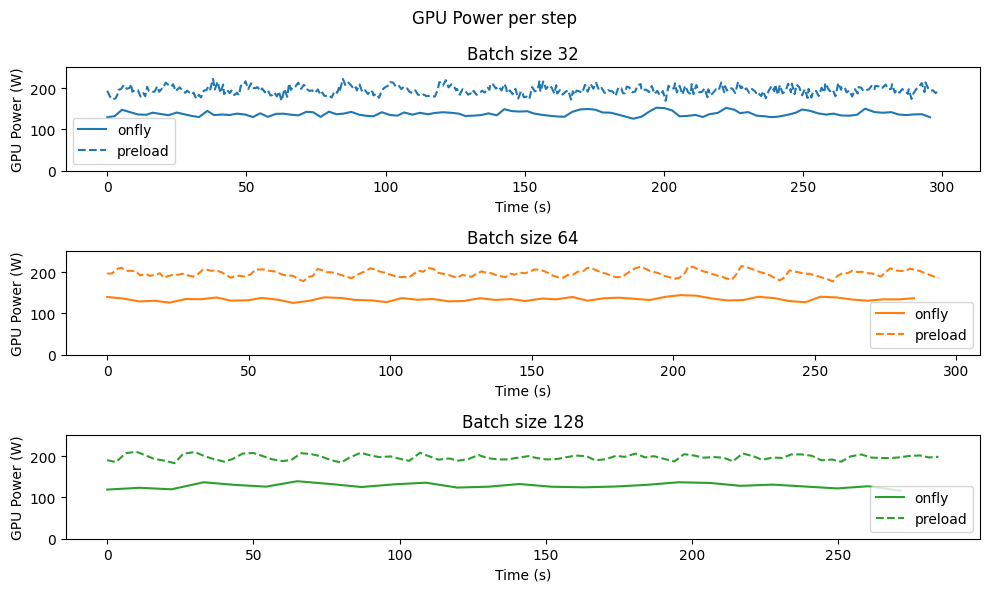

In [14]:
fig, ax = plt.subplots(3, 1, figsize=(10, 6), layout="tight")

for i, b in enumerate(batch_sizes):
    for m in modes:
        data = data_dict[(m, b)]
        ax[i].plot(data["timestamp"], data["gpu_power"], label=m, linestyle=linestyles[m], color=colours[b])
        ax[i].set_title(f"Batch size {b}")
        ax[i].set_xlabel("Time (s)")
        ax[i].set_ylabel("GPU Power (W)")
        ax[i].legend()
        ax[i].set_ylim(0, 250)

fig.suptitle("GPU Power per step")

Energy

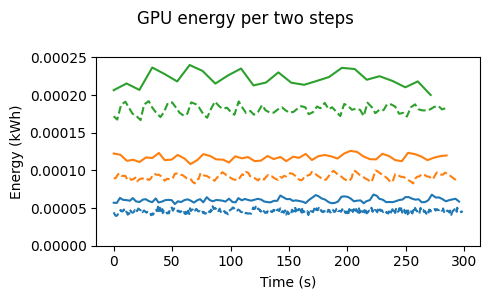

In [15]:
# combine all in one graph
fig, ax = plt.subplots(figsize=(5, 3), layout="tight")

for i, b in enumerate(batch_sizes):
    for m in modes:
        data = data_dict[(m, b)]
        ax.plot(data["timestamp"], data["gpu_energy"], label=f"{m}, {b}", linestyle=linestyles[m], color=colours[b])
        ax.set_xlabel("Time (s)")
        ax.set_ylabel("Energy (kWh)")

ax.set_ylim(0)
fig.suptitle("GPU energy per two steps")
fig.savefig(os.path.join(plot_dir,  "gpu_energy_step.png"), dpi=300, bbox_inches="tight")

Text(0.5, 0.98, 'GPU Energy per step')

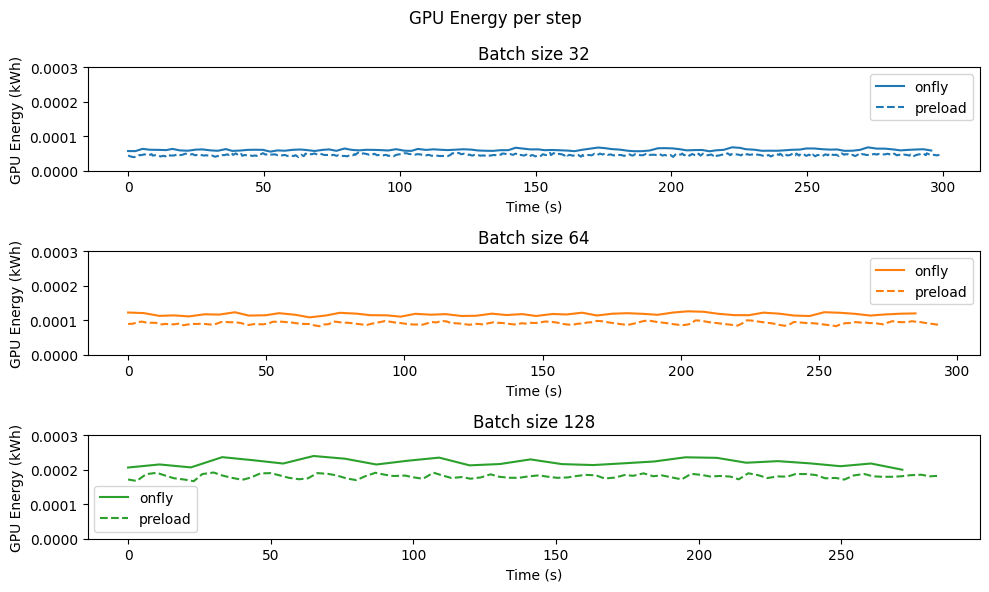

In [16]:
fig, ax = plt.subplots(3, 1, figsize=(10, 6), layout="tight")

for i, b in enumerate(batch_sizes):
    for m in modes:
        data = data_dict[(m, b)]
        ax[i].plot(data["timestamp"], data["gpu_energy"], label=m, linestyle=linestyles[m], color=colours[b])
        ax[i].set_title(f"Batch size {b}")
        ax[i].set_xlabel("Time (s)")
        ax[i].set_ylabel("GPU Energy (kWh)")
        ax[i].legend()
        ax[i].set_ylim(0, 0.0003)

fig.suptitle("GPU Energy per step")

C:\Users\Etomiuk\AppData\Local\Temp\ipykernel_49676\3549039493.py:7: MatplotlibDeprecationWarning: Passing label as a length 2 sequence when plotting a single dataset is deprecated in Matplotlib 3.9 and will error in 3.11.  To keep the current behavior, cast the sequence to string before passing.
  ax.plot(data["timestamp"], data["cpu_energy"], label=(m, b), linestyle=linestyles[m], color=colours[b])


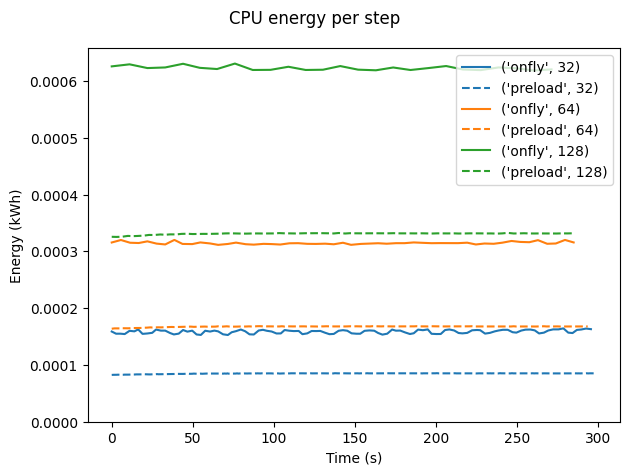

In [17]:
# combine all in one graph
fig, ax = plt.subplots( layout="tight")

for i, b in enumerate(batch_sizes):
    for m in modes:
        data = data_dict[(m, b)]
        ax.plot(data["timestamp"], data["cpu_energy"], label=(m, b), linestyle=linestyles[m], color=colours[b])
        ax.set_xlabel("Time (s)")
        ax.set_ylabel("Energy (kWh)")
        ax.legend()

ax.set_ylim(0)
fig.suptitle("CPU energy per step")
fig.savefig(os.path.join(plot_dir, "gpu_power_per_step.png"))

Text(0.5, 0.98, 'CPU Energy per step')

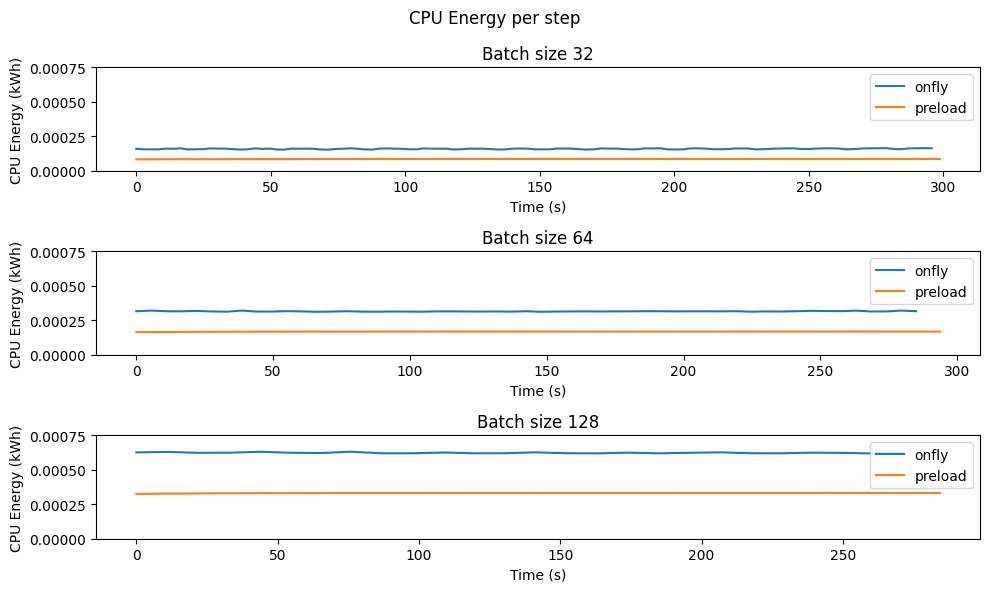

In [18]:
fig, ax = plt.subplots(3, 1, figsize=(10, 6), layout="tight")

for i, b in enumerate(batch_sizes):
    for m in modes:
        data = data_dict[(m, b)]
        ax[i].plot(data["timestamp"], data["cpu_energy"], label=m)
        ax[i].set_title(f"Batch size {b}")
        ax[i].set_xlabel("Time (s)")
        ax[i].set_ylabel("CPU Energy (kWh)")
        ax[i].legend()
        ax[i].set_ylim(0, 0.00075)

fig.suptitle("CPU Energy per step")

C:\Users\Etomiuk\AppData\Local\Temp\ipykernel_49676\2590152371.py:7: MatplotlibDeprecationWarning: Passing label as a length 2 sequence when plotting a single dataset is deprecated in Matplotlib 3.9 and will error in 3.11.  To keep the current behavior, cast the sequence to string before passing.
  ax.plot(data["timestamp"], data["ram_energy"], label=(m, b), linestyle=linestyles[m], color=colours[b])


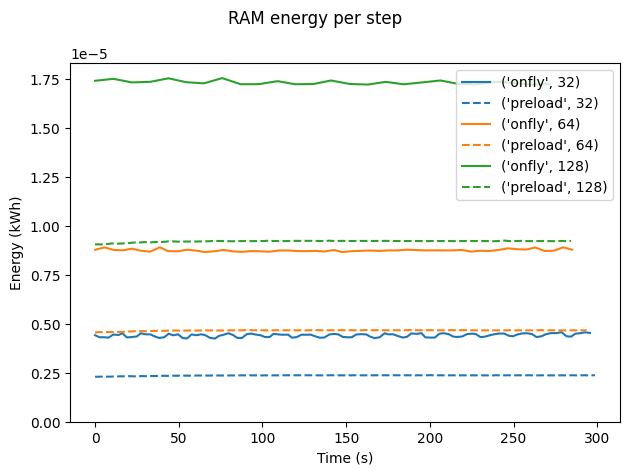

In [19]:
# combine all in one graph
fig, ax = plt.subplots( layout="tight")

for i, b in enumerate(batch_sizes):
    for m in modes:
        data = data_dict[(m, b)]
        ax.plot(data["timestamp"], data["ram_energy"], label=(m, b), linestyle=linestyles[m], color=colours[b])
        #ax.set_title(f"Batch size {b}")
        ax.set_xlabel("Time (s)")
        ax.set_ylabel("Energy (kWh)")
        ax.legend()

ax.set_ylim(0)
fig.suptitle("RAM energy per step")
fig.savefig(os.path.join(plot_dir, "gpu_power_per_step.png"))

Text(0.5, 0.98, 'RAM Energy per step')

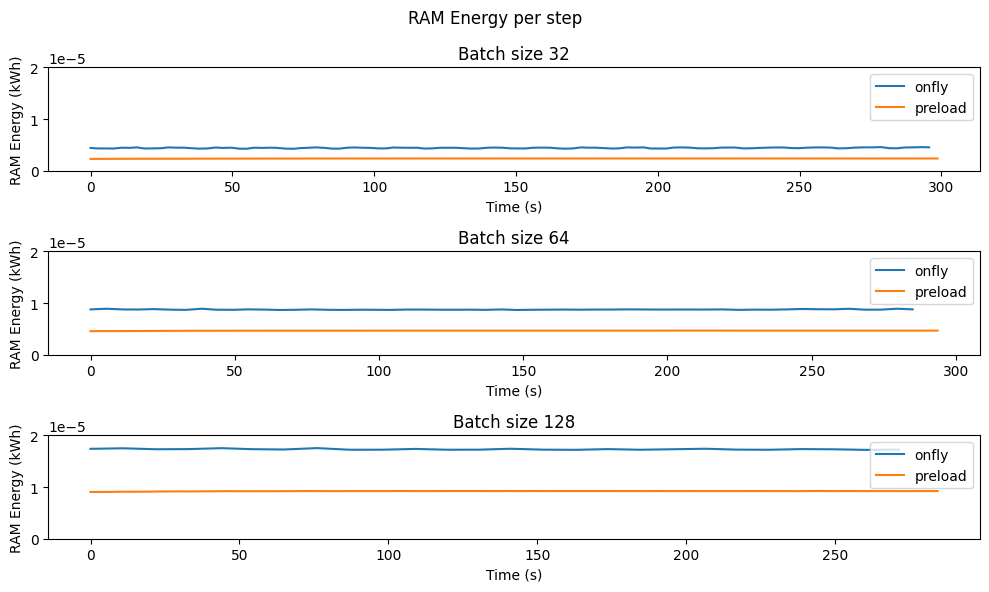

In [20]:
fig, ax = plt.subplots(3, 1, figsize=(10, 6), layout="tight")

for i, b in enumerate(batch_sizes):
    for m in modes:
        data = data_dict[(m, b)]
        ax[i].plot(data["timestamp"], data["ram_energy"], label=m)
        ax[i].set_title(f"Batch size {b}")
        ax[i].set_xlabel("Time (s)")
        ax[i].set_ylabel("RAM Energy (kWh)")
        ax[i].legend()
        ax[i].set_ylim(0, 2e-5)

fig.suptitle("RAM Energy per step")

### Calculate the ratios of duration, energy, power, and carbon emissions between both modes.

In [21]:
print(f"Batch size 32: {data_dict[("onfly", 32)]["gpu_power"].mean()}")
print(f"Batch size 64: {data_dict[("onfly", 64)]["gpu_power"].mean()}")
print(f"Batch size 128: {data_dict[("onfly", 128)]["gpu_power"].mean()}")

Batch size 32: 137.79019054720877
Batch size 64: 134.13953248519024
Batch size 128: 127.94853364975226


Duration

In [22]:
# calculate what the increase is between onfly and preload
for b in batch_sizes:
    data_preload = data_dict[("preload", b)]
    data_onfly = data_dict[("onfly", b)]

    print(f"Batch size {b}: duration per 2 steps for onfly is {data_onfly["duration"].mean()/data_preload["duration"].mean()}x larger than for preload.")

Batch size 32: duration per 2 steps for onfly is 1.8666663023789993x larger than for preload.
Batch size 64: duration per 2 steps for onfly is 1.8775213366100858x larger than for preload.
Batch size 128: duration per 2 steps for onfly is 1.8815184870069381x larger than for preload.


In [23]:
# calculate what the increase is between onfly and preload
for m in modes:
    data_32 = data_dict[(m, 32)]
    data_64 = data_dict[(m, 64)]
    data_128 = data_dict[(m, 128)]


    print(f"Mode {m}: duration per 2 steps for 128 is {data_128["duration"].mean()/data_64["duration"].mean()}x larger than for 64, and {data_128["duration"].mean()/data_32["duration"].mean()}x larger than for 32.")

Mode onfly: duration per 2 steps for 128 is 1.9798413983763175x larger than for 64, and 3.9285345840968624x larger than for 32.
Mode preload: duration per 2 steps for 128 is 1.9756353680418435x larger than for 64, and 3.8975238226490347x larger than for 32.


Energy

In [24]:
# calculate what the increase is between onfly and preload
for b in batch_sizes:
    data_preload = data_dict[("preload", b)]
    data_onfly = data_dict[("onfly", b)]

    print(f"Batch size {b}: GPU energy per 2 steps for onfly is {data_onfly["gpu_energy"].mean()/data_preload["gpu_energy"].mean()}x larger than for preload.")

Batch size 32: GPU energy per 2 steps for onfly is 1.3202801217672546x larger than for preload.
Batch size 64: GPU energy per 2 steps for onfly is 1.282312626262026x larger than for preload.
Batch size 128: GPU energy per 2 steps for onfly is 1.2238297218198828x larger than for preload.


In [25]:
# calculate what the increase is between onfly and preload
for m in modes:
    data_32 = data_dict[(m, 32)]
    data_64 = data_dict[(m, 64)]
    data_128 = data_dict[(m, 128)]


    print(f"Mode {m}: GPU energy per 2 steps for 128 is {data_128["gpu_energy"].mean()/data_64["gpu_energy"].mean()}x larger than for 64, and {data_128["gpu_energy"].mean()/data_32["gpu_energy"].mean()}x larger than for 32.")

Mode onfly: GPU energy per 2 steps for 128 is 1.8886577394090858x larger than for 64, and 3.6492007240315862x larger than for 32.
Mode preload: GPU energy per 2 steps for 128 is 1.978910646434032x larger than for 64, and 3.9367953648919967x larger than for 32.


In [26]:
# calculate what the increase is between onfly and preload
for b in batch_sizes:
    data_preload = data_dict[("preload", b)]
    data_onfly = data_dict[("onfly", b)]

    print(f"Batch size {b}: CPU energy per 2 steps for onfly is {data_onfly["cpu_energy"].mean()/data_preload["cpu_energy"].mean()}x larger than for preload.")

Batch size 32: CPU energy per 2 steps for onfly is 1.867798493889738x larger than for preload.
Batch size 64: CPU energy per 2 steps for onfly is 1.878205327250439x larger than for preload.
Batch size 128: CPU energy per 2 steps for onfly is 1.881377752379594x larger than for preload.


In [27]:
# calculate what the increase is between onfly and preload
for b in batch_sizes:
    data_preload = data_dict[("preload", b)]
    data_onfly = data_dict[("onfly", b)]

    print(f"Batch size {b}: RAM energy per 2 steps for onfly is {data_onfly["ram_energy"].mean()/data_preload["ram_energy"].mean()}x larger than for preload.")

Batch size 32: RAM energy per 2 steps for onfly is 1.8678646124487164x larger than for preload.
Batch size 64: RAM energy per 2 steps for onfly is 1.8782352387214376x larger than for preload.
Batch size 128: RAM energy per 2 steps for onfly is 1.8813949854993635x larger than for preload.


In [28]:
# calculate what the increase is between onfly and preload
for b in batch_sizes:
    data_preload = data_dict[("preload", b)]
    data_onfly = data_dict[("onfly", b)]

    print(f"Batch size {b}: total energy per 2 steps for onfly is {data_onfly["energy_consumed"].mean()/data_preload["energy_consumed"].mean()}x larger than for preload.")

Batch size 32: total energy per 2 steps for onfly is 1.678892300842604x larger than for preload.
Batch size 64: total energy per 2 steps for onfly is 1.6715255104069435x larger than for preload.
Batch size 128: total energy per 2 steps for onfly is 1.6531442561790692x larger than for preload.


In [29]:
# calculate what the increase is between onfly and preload
for b in batch_sizes:
    data_preload = data_dict[("preload", b)]
    data_onfly = data_dict[("onfly", b)]

    print(f"Batch size {b}: GPU power per 2 steps for onfly is {data_onfly["gpu_power"].mean()/data_preload["gpu_power"].mean()}x larger than for preload.")

Batch size 32: GPU power per 2 steps for onfly is 0.7069744875367517x larger than for preload.
Batch size 64: GPU power per 2 steps for onfly is 0.6827221228821198x larger than for preload.
Batch size 128: GPU power per 2 steps for onfly is 0.650473637767243x larger than for preload.


In [30]:
# calculate what the increase is between onfly and preload
for b in batch_sizes:
    data_preload = data_dict[("preload", b)]
    data_onfly = data_dict[("onfly", b)]

    print(f"Batch size {b}: carbon emissions per 2 steps for onfly is {data_onfly["emissions"].mean()/data_preload["emissions"].mean()}x larger than for preload.")

Batch size 32: carbon emissions per 2 steps for onfly is 1.6788923008423327x larger than for preload.
Batch size 64: carbon emissions per 2 steps for onfly is 1.6715255104068285x larger than for preload.
Batch size 128: carbon emissions per 2 steps for onfly is 1.653144256179009x larger than for preload.
